In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries --!

import torch
import torch.nn.functional as F
import random
import numpy as np
import matplotlib.pyplot as plt

import util_data
import util_nn

### Creating baseline dataset

In [2]:
class transition_dataset(torch.utils.data.Dataset):
    def __init__(self, states, actions, next_states):
        self.states = states
        self.actions = actions
        self.targets = next_states - states  # delta

    def __len__(self):
        return len(self.states)

    def __getitem__(self, idx):
        return self.states[idx], self.actions[idx], self.targets[idx]

def bootstrap_indices(n, size):
    return np.random.choice(n, size=size, replace=True)

def normalize_standard(timeseries, mean, std):
    return (timeseries - mean) / std

skip_nsample = 150
data_nsample = 10_000 - skip_nsample
data = util_data.read_datafile('../../data/mujoco/hopper_all_0', data_nsample)
print(f'read data shape: {data.shape}')

state_ndim = 11
action_ndim = 3
states, actions = torch.split(data, [state_ndim, action_ndim], dim=-1)
print(f'read states shape: {states.shape}')
print(f'read actions shape: {actions.shape}')

std_min = torch.tensor(1e-3, dtype=torch.float32)

s_mean = [s.mean() for s in torch.split(states, 1, dim=-1)]
s_std = [torch.maximum(s.std(), std_min) for s in torch.split(states, 1, dim=-1)]
a_mean = [a.mean() for a in torch.split(actions, 1, dim=-1)]
a_std = [torch.maximum(a.std(), std_min) for a in torch.split(actions, 1, dim=-1)]

states = torch.cat([
    normalize_standard(s, mean, std) for s, mean, std in zip(torch.split(states, 1, dim=-1), s_mean, s_std)], dim=-1)

actions = torch.cat([
    normalize_standard(a, mean, std) for a, mean, std in zip(torch.split(actions, 1, dim=-1), a_mean, a_std)], dim=-1)

train_states = states[0, :-1]
train_next_states = states[0, 1:]
train_actions = actions[0, :-1]
print(f'states for training shape: {train_states.shape}')
print(f'next states for training shape: {train_next_states.shape}')
print(f'action for training shape: {train_actions.shape}')

dataset = transition_dataset(train_states, train_actions, train_next_states)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=128, shuffle=True)

read data shape: torch.Size([1, 9850, 14])
read states shape: torch.Size([1, 9850, 11])
read actions shape: torch.Size([1, 9850, 3])
states for training shape: torch.Size([9849, 11])
next states for training shape: torch.Size([9849, 11])
action for training shape: torch.Size([9849, 3])


### Modeling dynamics as a Mixture of Experts

In [3]:
class expert(torch.nn.Module):
    def __init__(self, i_ndim, o_ndim, hidden=256):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(i_ndim, hidden),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden, hidden),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden, o_ndim)
        )

    def forward(self, x):
        return self.net(x)

class moe_dynamics(torch.nn.Module):
    def __init__(self, s_ndim, a_ndim, nexpert=3):
        super().__init__()

        self.i_ndim = s_ndim + a_ndim
        self.o_ndim = s_ndim

        self.experts = torch.nn.ModuleList([expert(self.i_ndim, self.o_ndim) for _ in range(nexpert)])

        # --! gating network
        self.gate = torch.nn.Sequential(
            torch.nn.Linear(self.i_ndim, 128),
            torch.nn.ReLU(),
            torch.nn.Linear(128, nexpert)
        )

    def forward(self, s, a):
        x = torch.cat([s, a], dim=-1)

        logits = self.gate(x)
        weights = F.softmax(logits, dim=-1)  # (B, K)

        outputs = torch.stack(
            [expert(x) for expert in self.experts],
            dim=-1
        )  # (B, state_dim, K)

        weights_expanded = weights.unsqueeze(1)  # (B, 1, K)
        out = (outputs * weights_expanded).sum(-1)

        return out, weights


### Training the Mixture of Experts

In [4]:
def train_moe(model, dataloader, nepoch=100):

    opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-8)
    losses = []
    for epoch in range(nepoch):
        total_loss = 0.0
        for s, a, target in dataloader:
            opt.zero_grad()

            pred, weights = model(s, a)

            mse = F.mse_loss(pred, target)
            entropy = -(weights * torch.log(weights + 1e-8)).sum(dim=-1)
            entropy = entropy.mean()
            loss = mse - 0.01 * entropy

            loss.backward()
            opt.step()

            total_loss += loss.item()

        if epoch % 20 == 0:
            print(f"epoch {epoch}, loss: {total_loss / len(dataloader):.6f}")

s_ndim = 11
a_ndim = 3

model = moe_dynamics(s_ndim, a_ndim, nexpert=4)
model.train()
train_moe(model, dataloader, nepoch=500)

epoch 0, loss: -0.002196
epoch 20, loss: -0.009638
epoch 40, loss: -0.009998
epoch 60, loss: -0.010238
epoch 80, loss: -0.010424
epoch 100, loss: -0.010444
epoch 120, loss: -0.010836
epoch 140, loss: -0.011014
epoch 160, loss: -0.011016
epoch 180, loss: -0.010934
epoch 200, loss: -0.011347
epoch 220, loss: -0.011446
epoch 240, loss: -0.011465
epoch 260, loss: -0.011370
epoch 280, loss: -0.011680
epoch 300, loss: -0.011662
epoch 320, loss: -0.011797
epoch 340, loss: -0.011852
epoch 360, loss: -0.011969
epoch 380, loss: -0.012066
epoch 400, loss: -0.011643
epoch 420, loss: -0.011870
epoch 440, loss: -0.011743
epoch 460, loss: -0.012148
epoch 480, loss: -0.012165


In [5]:
def rollout(model, s0, actions):
    s = s0
    traj = [s0]

    for a in actions:
        delta, _ = model(s.unsqueeze(0), a.unsqueeze(0))
        delta = delta.squeeze(0)
        s = s + delta
        traj.append(s)

    return torch.stack(traj)

model.eval()
util_nn.freeze_module(model)

s0 = states[0, 0]
rollout_traj = rollout(model, s0, actions[0])
print(f'rollout shape: {rollout_traj.shape}')

rollout shape: torch.Size([9851, 11])


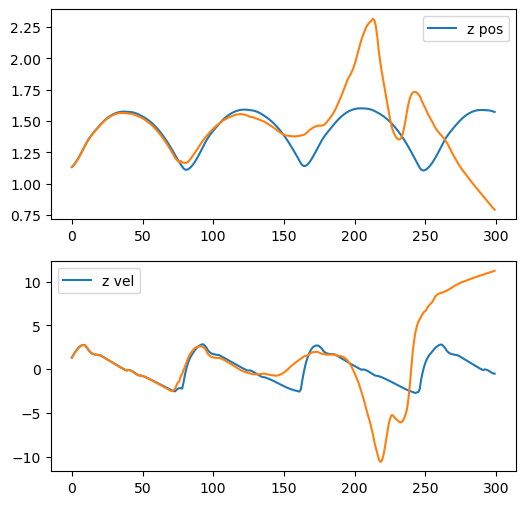

In [9]:
def denormalize_standard(timeseries, mean, std):
    return timeseries * std + mean

disp_end = 300
datasaved = False

with torch.no_grad():
    plot_rollout_traj = torch.unsqueeze(rollout_traj, 0)
    plot_rollout_traj = torch.cat([
        denormalize_standard(
            s, mean, std) for s, mean, std in zip(torch.split(plot_rollout_traj, 1, dim=-1), s_mean, s_std)], dim=-1)
    plot_states = torch.cat([
        denormalize_standard(
            s, mean, std) for s, mean, std in zip(torch.split(states, 1, dim=-1), s_mean, s_std)], dim=-1)

    plt.figure(figsize=(6,6))

    plt.subplot(2,1,1)
    plt.plot(plot_states[0, :disp_end, 0], label='z pos')
    plt.plot(plot_rollout_traj[0, :disp_end, 0])
    plt.legend()

    plt.subplot(2,1,2)
    plt.plot(plot_states[0, :disp_end, 6], label='z vel')
    plt.plot(plot_rollout_traj[0, :disp_end, 6])
    plt.legend()

    plt.show()

    if datasaved:
        save_step = torch.arange(states.shape[1]).reshape(1, -1, 1)
        savedata = np.concatenate([
            save_step[:1, :disp_end, :1],
            plot_states[:1, :disp_end, :1], plot_states[:1, :disp_end, [6]],
            plot_rollout_traj[:1, :disp_end, :1], plot_rollout_traj[:1, :disp_end, [6]]], axis=2)
        util_data.write_datafile(f'../../results/mujoco/hopper_moe_rollout', savedata, delim=' ')

In [10]:
modelsaved = False

if modelsaved:
    torch.save(model.state_dict(), '../../models/mujoco/hopper_moe_checkpoint.pth')